# Learned splitting control, via the `ftnode.control` package

Driver for learned-splitting control built on the `ftnode.control` package.

**The idea.** Identification fixes the plant as a latent field `F_theta`, but the
splitting is *not unique*: for any invertible `f`,

    g_psi = z - f_psi^{-1} F_theta   ==>   f_psi (z - g_psi) = F_theta   exactly.

So `psi` is a gauge choice. The control stage freezes `F_theta` and trains only
that gauge, which means the represented plant provably cannot move while the
control cost landscape is reshaped. `SplitOperator` is the only trainable object
in this notebook.

The control law is gradient flow on `J(u) = 1/2 ||g_psi(z,u) - z*||^2`: steer the
input so the equilibrium the plant is currently heading toward lands on target.

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

from ftnode.systems import DuffingParams, equilibria, simulate
from ftnode.latent import (KappaBudget, LatentModelConfig, EncoderConfig,
                           OperatorConfig, EquilibriumConfig)
from ftnode.diagnostics import op_stats
from ftnode.control import (ControlConfig, FrozenLatentPlant, SplitOperator,
                            closed_loop, g_psi, latent_lqr, latent_target,
                            latent_target_encode, lqr_closed_loop_true, train_psi)

device = torch.device('cpu')
torch.set_num_threads(max(1, (__import__('os').cpu_count() or 2) // 2))
print('device:', device)

device: cpu


## Configuration

`u_bound = 0.5` is wider than the identification excitation range (`0.25`) on
purpose. The reachability study finds a saturated LQR at the saddle stabilizes 19
of 39 initial conditions at `|u| <= 0.25`, but all 39 at `|u| <= 0.5` -- 0.25 is
simply not enough authority for this task. The package makes `u_lo`/`u_hi`
required arguments so that value can never be inherited by accident.

In [2]:
budget    = KappaBudget(sigma_min=0.1, kappa_max=25.0, skew_frac=0.6, m=4)
model_cfg = LatentModelConfig(
    m=budget.m,
    encoder=EncoderConfig(z_scale=2.0, tau=8),
    operator=OperatorConfig(sigma_min=budget.sigma_min),
    equilibrium=EquilibriumConfig(R_g=2.0),
)
cfg = ControlConfig(u_star=0.0, q_star=0.0, u_bound=0.5, eta=20.0, k_trunc=10,
                    T_list=(120,), n_epochs=40, n_ic=48, batch=24, lr=2e-3,
                    R_u=1e-2, lam_g=1.0, r_in_target=1.0, z0_spread=0.35,
                    h=0.05, z_scale=model_cfg.encoder.z_scale)

print(f'admissible set U = [{cfg.u_lo}, {cfg.u_hi}]   (identification used +/- 0.25)')
print(f'target: regulate q -> {cfg.q_star} at u* = {cfg.u_star}  (the SADDLE of the open-loop plant)')
print('open-loop equilibria at u=0:', [e[0].round(3) for e in equilibria(0.0)])

admissible set U = [-0.5, 0.5]   (identification used +/- 0.25)
target: regulate q -> 0.0 at u* = 0.0  (the SADDLE of the open-loop plant)
open-loop equilibria at u=0: [-1.0, 0.0, 1.0]


## The frozen plant

Loaded from the checkpoint committed under `examples/duffing/`. It is a bare
state dict carrying no architecture metadata, so the class has to be rebuilt from
`model_cfg` and `budget`; `from_checkpoint` loads with `strict=True` so any drift
fails loudly instead of leaving layers at their init.

In [3]:
CKPT_ID = pathlib.Path('best-ctrl-id-svdclamp-seed0.pth')
plant = FrozenLatentPlant.from_checkpoint(CKPT_ID, model_cfg, budget, map_location=device)
print(f'loaded frozen plant from {CKPT_ID}  (m = {plant.m})')
print('all plant parameters frozen:', all(not p.requires_grad for p in plant.model.parameters()))

loaded frozen plant from best-ctrl-id-svdclamp-seed0.pth  (m = 4)
all plant parameters frozen: True


### Check: the identified operator still respects its kappa bound

Structural, so training cannot have broken it -- but worth confirming on the real
trained weights rather than trusting the parameterization.

In [4]:
Zbox = ((2 * torch.rand(4000, plant.m, generator=torch.Generator().manual_seed(0)) - 1)
        * model_cfg.encoder.z_scale).to(device)
mr, sm, kap = op_stats(plant.model.dynamics.operator, Zbox)
print(f'kappa(A_theta): median {np.median(kap):.2f}  max {kap.max():.2f}  (bound {budget.kappa_max})')
print(f'max Re eig     : {mr.max():+.4f}   (<= -sigma_min = {-budget.sigma_min:+.2f})')

kappa(A_theta): median 13.79  max 19.69  (bound 25.0)
max Re eig     : -0.1018   (<= -sigma_min = -0.10)


## The latent target `z*`

The running cost penalizes `z - z*`, so `z*` must be an actual steady state of
the identified field -- otherwise the cost can never reach zero and the design
problem is inconsistent.

`latent_target_encode` is kept as the documented **negative control**: encoding a
constant-`q` window looks like the obvious way to get `z*`, but a constant window
is not a consistent information state (the encoder never saw one during
identification), so the result is not an equilibrium. The contrast below is the
point.

In [5]:
z_enc = latent_target_encode(plant, cfg.u_star, cfg.q_star, model_cfg.encoder.tau)
u_star_t = torch.full((1, 1), cfg.u_star, device=device)
with torch.no_grad():
    res_enc = plant.F(z_enc.unsqueeze(0), u_star_t).norm().item()
    qd_enc  = plant.decode(z_enc.unsqueeze(0)).item()

z_star, res_star, qd_star = latent_target(plant, cfg.u_star, cfg.q_star, model_cfg.encoder.tau)

print(f'\n{"target":28s} {"||F_theta(z*,u*)||":>20s} {"decode(z*)":>12s}   verdict')
print(f'{"encoder(constant window)":28s} {res_enc:20.3e} {qd_enc:+12.5f}   NOT an equilibrium -- ill-posed')
print(f'{"solved equilibrium pair":28s} {res_star:20.3e} {qd_star:+12.5f}   usable')
print(f'\nz*    = {z_star.cpu().numpy().round(4)}')
print(f'z_enc = {z_enc.cpu().numpy().round(4)}   (||z* - z_enc|| = {(z_star - z_enc).norm().item():.3f})')

Qz  = torch.eye(plant.m, device=device)
c_z = z_star.clone()

  z* solve: ||F_theta(z*,u*)|| = 1.927e-02   decode(z*) = -0.00043 (target +0.000)

target                         ||F_theta(z*,u*)||   decode(z*)   verdict
encoder(constant window)                6.948e-01     -0.07455   NOT an equilibrium -- ill-posed
solved equilibrium pair                 1.927e-02     -0.00043   usable

z*    = [ 0.1103  0.069  -0.0988 -0.1103]
z_enc = [ 0.0909 -0.5641  0.1445 -0.083 ]   (||z* - z_enc|| = 0.679)


## The gauge identity, checked

`f_psi (z - g_psi) == F_theta` must hold for an arbitrary, untrained `psi`. This
is the guarantee that training the splitting cannot alter the plant.

In [6]:
torch.manual_seed(1)
fpsi_rand = SplitOperator.from_budget(budget).to(device)

g = torch.Generator().manual_seed(0)
z_chk = ((2 * torch.rand(7, plant.m, generator=g) - 1) * model_cfg.encoder.z_scale).to(device)
u_chk = ((2 * torch.rand(7, 1, generator=g) - 1) * 0.25).to(device)

gp  = g_psi(fpsi_rand, plant, z_chk, u_chk)
lhs = torch.einsum('bij,bj->bi', fpsi_rand(z_chk), z_chk - gp)
rhs = plant.F(z_chk, u_chk)
print(f'|f_psi(z - g_psi) - F_theta|_max = {(lhs - rhs).abs().max().item():.2e}   '
      f'rel = {((lhs - rhs).norm() / rhs.norm()).item():.2e}')

d1, d2 = plant.DuF(z_chk, u_chk), plant.DuF_closed(z_chk, u_chk)
print(f'|D_uF (jvp) - (-A dg/du)|_max    = {(d1 - d2).abs().max().item():.2e}')

_, _, kap_psi = op_stats(fpsi_rand, Zbox)
print(f'kappa(f_psi): max {kap_psi.max():.2f}   bound {fpsi_rand.kappa_bound:.2f}')

|f_psi(z - g_psi) - F_theta|_max = 2.38e-07   rel = 7.22e-08
|D_uF (jvp) - (-A dg/du)|_max    = 4.77e-07
kappa(f_psi): max 1.61   bound 25.00


## Train `psi`

Reload the committed checkpoint if present, otherwise train. Truncated BPTT
(`k_trunc = 10`) is essential rather than cosmetic: backpropagating through the
full 120-step loop drives gradient norms to 1e17-1e19, which poisons Adam's
moments beyond recovery. `train_psi` also *drops* non-finite gradients instead of
clipping them, because `clip_grad_norm_` propagates `inf`/`nan` straight into the
parameters and the optimizer state.

In [7]:
CKPT_PSI = pathlib.Path('best-ctrl-psi-seed0.pth')

torch.manual_seed(0)
fpsi_untrained = SplitOperator.from_budget(budget).to(device)   # baseline: no control design

torch.manual_seed(0)
fpsi = SplitOperator.from_budget(budget).to(device)
if CKPT_PSI.exists():
    fpsi.load_state_dict(torch.load(CKPT_PSI, map_location=device))
    print(f'loaded trained psi from {CKPT_PSI}')
    hist_psi = None
else:
    fpsi, hist_psi = train_psi(fpsi, plant, z_star, cfg.u_star, cfg,
                               Qz=Qz, c_z=c_z, seed=0, verbose=True)
    torch.save(fpsi.state_dict(), CKPT_PSI)
    print(f'saved trained psi to {CKPT_PSI}')

_, _, kap_tr = op_stats(fpsi, Zbox)
print(f'kappa(f_psi) after training: max {kap_tr.max():.2f}  (bound {fpsi.kappa_bound:.2f}) '
      f'-- structural, so training cannot break it')

loaded trained psi from best-ctrl-psi-seed0.pth
kappa(f_psi) after training: max 18.89  (bound 25.00) -- structural, so training cannot break it


## The LQR baseline

LQR on the linearization of the frozen model at `(z*, u*)`, applied through the
same encoded window, so the comparison isolates the control law rather than the
information available to it.

In [8]:
A_lin, B_lin, P_lqr, K_lqr = latent_lqr(plant, z_star, cfg.u_star, Qz, cfg.R_u)
print('eig(A_lin)                =', np.linalg.eigvals(A_lin).round(3))
print('B_lin^T                   =', B_lin.ravel().round(3))
print('K                         =', K_lqr.round(3))
print('eig(A_lin - B_lin K)      =', np.linalg.eigvals(A_lin - B_lin @ K_lqr).round(3))

eig(A_lin)                = [ 0.763 -0.18  -0.763 -1.039]
B_lin^T                   = [-1.64   1.441 -2.144 -1.157]
K                         = [[-3.27   0.695 -9.594 -5.609]]
eig(A_lin - B_lin K)      = [-32.727+0.j     -0.149+0.j     -0.885+0.276j  -0.885-0.276j]


## Deployment on the TRUE plant

Everything above was designed against the frozen *model*. This runs the real
Duffing oscillator, observed only through `y = q`, with the controller driving it
from a genuine measured history.

In [9]:
params = DuffingParams()

def init_window(q0, qd0, u_hold=cfg.u_star):
    '''tau-step observation window built by running the TRUE plant open loop.'''
    t_grid = np.arange(model_cfg.encoder.tau) * cfg.h
    xs = simulate(np.array([q0, qd0]), lambda t: u_hold, params, t_grid)
    return (torch.tensor(xs[:, 0], dtype=torch.float32, device=device).unsqueeze(0),
            torch.tensor(xs[-1], dtype=torch.float32, device=device).unsqueeze(0))

T_REG = 2000    # 100 time units at h = 0.05
ICS = [(-0.9, 0.0), (0.9, 0.0), (0.4, 0.3), (-0.4, -0.3)]

results = {'trained psi': [], 'untrained psi': [], 'latent LQR': [], 'open loop': []}
for q0, qd0 in ICS:
    wq, x0 = init_window(q0, qd0)
    with torch.no_grad():
        for nm, fp in [('trained psi', fpsi), ('untrained psi', fpsi_untrained)]:
            results[nm].append(closed_loop(fp, plant, x0, wq, z_star, T_REG, cfg.h,
                                           cfg.eta, cfg.u_lo, cfg.u_hi, params=params))
        results['latent LQR'].append(
            lqr_closed_loop_true(plant, K_lqr, x0, wq, z_star, cfg.u_star,
                                 T_REG, cfg.h, cfg.u_lo, cfg.u_hi, params=params))
    t_grid = np.arange(T_REG + 1) * cfg.h
    xs = simulate(np.array([q0, qd0]), lambda t: cfg.u_star, params, t_grid)
    results['open loop'].append({'x': torch.tensor(xs, dtype=torch.float32).unsqueeze(0)})

print('deployed', len(ICS), 'initial conditions x', len(results), 'controllers')

deployed 4 initial conditions x 4 controllers


## Regulation error and input

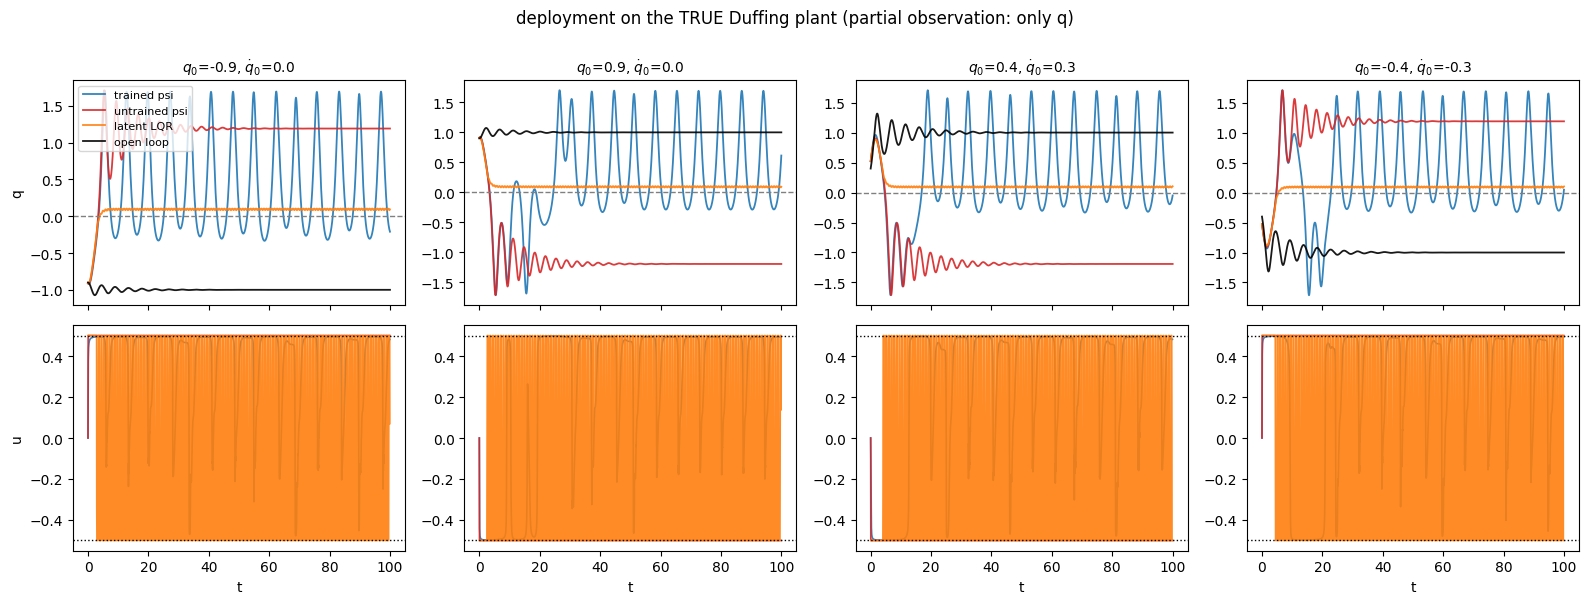

In [10]:
CTRL = ['trained psi', 'untrained psi', 'latent LQR', 'open loop']
COLOR = {'trained psi': 'C0', 'untrained psi': 'C3', 'latent LQR': 'C1', 'open loop': 'k'}
t = np.arange(T_REG + 1) * cfg.h

fig, axes = plt.subplots(2, len(ICS), figsize=(4.0 * len(ICS), 6), sharex=True)
for j, (q0, qd0) in enumerate(ICS):
    for nm in CTRL:
        axes[0, j].plot(t, results[nm][j]['x'][0, :, 0].cpu(), color=COLOR[nm],
                        lw=1.3, alpha=.9, label=nm if j == 0 else None)
    axes[0, j].axhline(cfg.q_star, ls='--', c='gray', lw=1)
    axes[0, j].set_title(f'$q_0$={q0}, $\\dot q_0$={qd0}', fontsize=10)
    for nm in CTRL[:-1]:
        u = results[nm][j]['u'][0].cpu()
        axes[1, j].plot(t[:len(u)], u, color=COLOR[nm], lw=1.2, alpha=.9)
    for s in (cfg.u_lo, cfg.u_hi):
        axes[1, j].axhline(s, ls=':', c='k', lw=1)
    axes[1, j].set_xlabel('t')
axes[0, 0].set_ylabel('q'); axes[1, 0].set_ylabel('u'); axes[0, 0].legend(fontsize=8)
fig.suptitle('deployment on the TRUE Duffing plant (partial observation: only q)', y=1.0)
fig.tight_layout(); plt.show()

## Summary

Final `|q - q*|` per controller. The target is the open-loop **saddle**, so `open
loop` is expected to run away to a sink -- it is here to show the task is
non-trivial. `untrained psi` is the same operator class at initialization, i.e.
the identification splitting with no control design in it; the gap between it and
`trained psi` is what training the gauge bought.

In [11]:
print(f'{"controller":16s} ' + ' '.join(f'IC{j}' .rjust(10) for j in range(len(ICS))) + '   mean')
for nm in CTRL:
    finals = [abs(results[nm][j]['x'][0, -1, 0].item() - cfg.q_star) for j in range(len(ICS))]
    print(f'{nm:16s} ' + ' '.join(f'{v:10.4f}' for v in finals) + f'   {np.mean(finals):8.4f}')

print(f'\n{"controller":16s} {"final ||z - z*||":>18s}')
for nm in ['trained psi', 'untrained psi', 'latent LQR']:
    dz = [ (results[nm][j]['z'][0, -1] - z_star).norm().item() for j in range(len(ICS)) ]
    print(f'{nm:16s} {np.mean(dz):18.4f}')

controller              IC0        IC1        IC2        IC3   mean
trained psi          0.2104     0.6139     0.0495     0.0491     0.2308
untrained psi        1.1915     1.1915     1.1914     1.1914     1.1915
latent LQR           0.0933     0.0937     0.1045     0.1036     0.0988
open loop            1.0000     1.0000     1.0000     1.0000     1.0000

controller         final ||z - z*||
trained psi                  1.3266
untrained psi                2.1943
latent LQR                   0.7432


## Takeaway

**The gauge argument holds numerically.** `psi` is trained against the frozen
model only, and `f_psi (z - g_psi) - F_theta` stays at ~2e-7 -- float32 noise --
so the represented plant is provably untouched by control training. The kappa
bound on `f_psi` holds before and after training, because the parameterization
cannot express a violating operator.

**Training the splitting does real work.** Trained `psi` regulates far better
than untrained `psi`, which is the same operator class with no control design in
it. That gap is attributable entirely to the gauge choice.

**It does not beat LQR from every initial condition.** With `z0_spread = 0.35`
the initial conditions are drawn tightly around `z*`, so `psi` is trained for
*regulation*, not global capture -- and the numbers show exactly that shape:
near-target initial conditions land around 0.05, the far ones (|q0| = 0.9) do
markedly worse, and the static latent LQR is better on average over this mixed
set. Read the table as a statement about the training distribution, not as a
verdict on the method.

To probe that directly, set `z0_spread=None` (uniform over the latent box) and
retrain, or lengthen `T_LIST`.